In [1]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from perceptron import Perceptron

## 1) Qu’est-ce qu’un Perceptron ? Lien neurone biologique ↔ perceptron

Le **Perceptron**, proposé par Frank Rosenblatt à la fin des années 1950, est l’un des premiers modèles de **neurone artificiel** utilisés en apprentissage automatique.  
Il s’agit d’un algorithme de **classification binaire** capable d’apprendre une règle de décision à partir de données étiquetées.

### Lien avec le neurone biologique

Un neurone biologique reçoit des signaux électriques via ses dendrites, les combine, puis émet un signal de sortie lorsque un certain **seuil d’activation** est dépassé.

Le perceptron s’inspire directement de ce mécanisme :
- les **entrées** sont des variables numériques $x_1, x_2, \dots, x_n$,
- chaque entrée est associée à un **poids** $w_1, w_2, \dots, w_n$,
- une **somme pondérée** est calculée,
- une **fonction seuil** décide de l’activation du neurone.

Bien que cette analogie soit utile sur le plan pédagogique, le perceptron reste un modèle mathématique très simplifié par rapport à la complexité d’un neurone biologique réel.

---

## 2) Fonction mathématique du Perceptron : équation et usage

### Fonction de décision

Le perceptron calcule d’abord un score :

$$
z = \sum_{j=1}^{n} w_j x_j + b
$$

Puis il applique une **fonction seuil** (fonction de Heaviside ou *step function*) :

$$
\hat{y} =
\begin{cases}
1 & \text{si } z \ge 0 \\
0 & \text{sinon}
\end{cases}
$$

### Définition des termes

- $x_j$ : la $j$-ième **feature** (entrée) du vecteur $x$  
- $w_j$ : le **poids** associé à $x_j$ (paramètre appris)  
- $b$ : le **biais** (*intercept*) qui décale le seuil de décision  
- $z$ : la **somme pondérée** (score avant activation)  
- $\hat{y}$ : la **prédiction** du modèle (0 ou 1)

### Usage

Le perceptron permet d’apprendre une **frontière de décision linéaire** :
- en 2 dimensions : une droite,
- en 3 dimensions : un plan,
- en dimension $n$ : un hyperplan.

Il est donc adapté uniquement aux problèmes **linéairement séparables**.

In [2]:
def score_perceptron(X, W, b):
    return X @ W + b

def activation_seuil(z):
    return (z >= 0).astype(int)

# Exemple simple
X = np.array([[1.0, 2.0],
              [-1.0, 0.5]])
W = np.array([[0.3],
              [0.7]])
b = -0.2

z = score_perceptron(X, W, b)
y_hat = activation_seuil(z)

z, y_hat

(array([[ 1.5 ],
        [-0.15]]),
 array([[1],
        [0]]))

## 3) Règle(s) d’apprentissage du Perceptron

L’apprentissage du perceptron repose sur une règle simple : les paramètres du modèle sont mis à jour **uniquement lorsqu’une erreur de classification est commise**.

### Règle d’apprentissage de Rosenblatt

Pour un exemple d’apprentissage $(x, y)$ avec $y \in \{0,1\}$ :

1. On calcule la prédiction $\hat{y}$.
2. On définit l’erreur :
$$
e = y - \hat{y}
$$
3. On met à jour les paramètres :
$$
w \leftarrow w + \eta \, e \, x
$$
$$
b \leftarrow b + \eta \, e
$$

où $\eta > 0$ est le **learning rate**.

### Intuition

- Si le modèle prédit $0$ alors que la vraie valeur est $1$, l’erreur est positive et les poids sont augmentés.
- Si le modèle prédit $1$ alors que la vraie valeur est $0$, l’erreur est négative et les poids sont diminués.
- Si la prédiction est correcte, aucun ajustement n’est effectué.

Cette règle converge si les données sont **linéairement séparables**, ce qui constitue à la fois la force et la principale limite du perceptron.

In [3]:
def perceptron_update(W, b, x, y, lr):
    z = float(x @ W + b)
    y_hat = 1 if z >= 0 else 0
    e = y - y_hat

    # Update
    W = W + lr * e * x
    b = b + lr * e
    return W, b, y_hat, e

# Exemple d'usage
W = np.zeros(2)  # 2 features
b = 0.0
x = np.array([1.5, -0.5])
y = 1
lr = 0.1

W, b, y_hat, e = perceptron_update(W, b, x, y, lr)
W, b, y_hat, e

(array([0., 0.]), 0.0, 1, 0)

## 4) Fonction d’activation utilisée par le Perceptron

Le perceptron utilise généralement une **fonction d’activation seuil**, aussi appelée **fonction de Heaviside** (*step function*).

Cette fonction transforme le score $z$ en une sortie binaire :

$$
\hat{y} =
\begin{cases}
1 & \text{si } z \ge 0 \\
0 & \text{sinon}
\end{cases}
$$

Contrairement aux réseaux de neurones modernes, cette fonction :
- n’est **pas différentiable**,
- ne permet pas l’utilisation de la descente de gradient,
- produit une sortie **discrète** (0 ou 1).

Le perceptron historique repose donc sur une **règle d’apprentissage directe**, et non sur une optimisation continue d’une fonction de coût.

### Implémentation Python de la fonction seuil

In [4]:
def activation_seuil(z):
  return (z >= 0).astype(int)

## 5) Processus d’entraînement du Perceptron

L’entraînement du perceptron consiste à ajuster ses paramètres afin de réduire les erreurs de classification sur les données d’apprentissage.

Étapes du processus d’entraînement
	1.	Initialiser les poids $w$ et le biais $b$ (souvent à zéro ou aléatoirement).
	2.	Parcourir les données d’apprentissage.
	3.	Pour chaque observation :
	•	calculer le score $z = w \cdot x + b$,
	•	appliquer la fonction seuil pour obtenir $\hat{y}$,
	•	calculer l’erreur $e = y - \hat{y}$,
	•	mettre à jour les paramètres si $e \neq 0$.
	4.	Répéter ce processus sur plusieurs époques jusqu’à convergence ou jusqu’à un nombre maximal d’itérations.

Schéma de mise à jour

$$
w \leftarrow w + \eta , (y - \hat{y}) , x
$$

$$
b \leftarrow b + \eta , (y - \hat{y})
$$

Exemple minimal en Python (une époque)

In [5]:
def train_one_epoch(X, y, W, b, lr):
    """
    Entraîne le perceptron sur une seule époque.
    """
    for i in range(len(X)):
        z = X[i] @ W + b
        y_hat = 1 if z >= 0 else 0
        error = y[i] - y_hat

        W = W + lr * error * X[i]
        b = b + lr * error

    return W, b


## 6) Limites du Perceptron

Malgré son importance historique, le perceptron présente plusieurs limitations majeures.

Limites principales
	•	Le perceptron ne peut résoudre que des problèmes linéairement séparables.
	•	Il est incapable de modéliser des relations non linéaires.
	•	Il échoue sur des problèmes simples comme le XOR.
	•	Il ne fournit pas de probabilité associée à ses prédictions.
	•	La convergence n’est garantie que si les données sont linéairement séparables.

Illustration conceptuelle (cas XOR)

Dans le cas du XOR, aucune droite ne permet de séparer correctement les classes, ce qui rend le perceptron inadapté à ce type de problème.

Ces limites ont conduit au développement :
	•	des perceptrons multicouches,
	•	des fonctions d’activation différentiables,
	•	et plus largement des réseaux de neurones profonds, fondements du Deep Learning moderne.

![Visualisation du problème XOR](pictures/xor_visualisation.png)

## 7) Utilisation du Perceptron

### Fake data

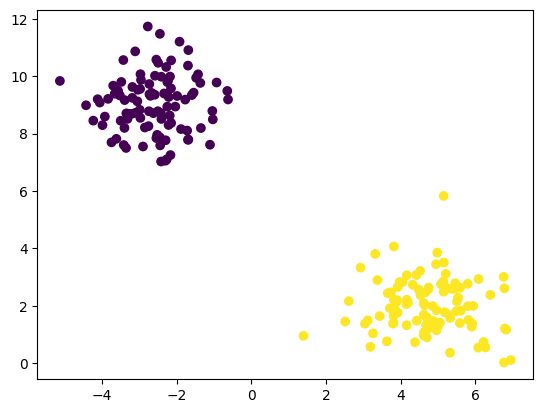

In [6]:
X, y = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y)

In [7]:
perceptron = Perceptron(learning_rate=0.01, n_epochs=50)
perceptron.fit(X, y)

print("Poids appris :", perceptron.W)
print("Biais appris :", perceptron.b)

Poids appris : [ 0.10355324 -0.0688079 ]
Biais appris : 0.0


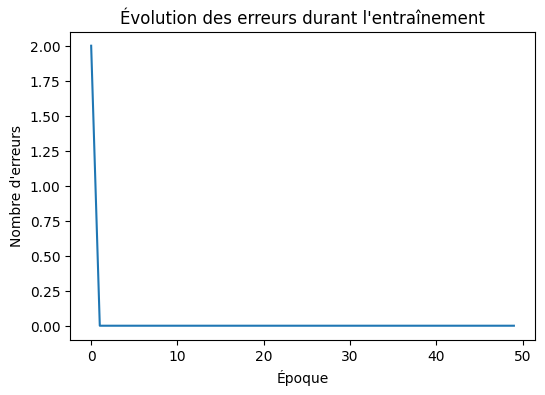

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(perceptron.errors_)
plt.xlabel("Époque")
plt.ylabel("Nombre d'erreurs")
plt.title("Évolution des erreurs durant l'entraînement")
plt.show()

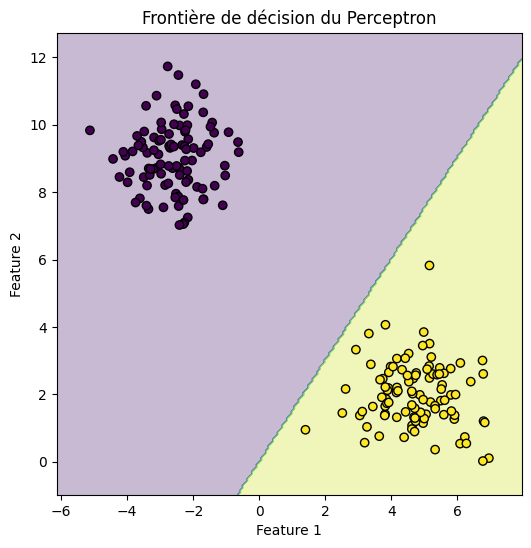

In [9]:
perceptron.plot(X, y)